# Project 04 — Cointegration and Statistical Arbitrage

## Part A — Static Hedge Ratio (Synthetic Data)
Demonstrates the full cointegration pipeline on synthetic data where the true
relationship is known. OLS recovers the true hedge ratio, ADF confirms stationarity,
and OU process extracts the mean reversion half-life.

In [1]:
import yfinance as yf
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# os.makedirs("./data", exist_ok=True)
# prices = yf.download(["SPY", "GLD", "GDX", "TLT", "^VIX"], start="2010-01-01", auto_adjust=True, progress=False)["Close"]
# prices.to_pickle("./data/prices.pkl")
prices = pd.read_pickle("./data/prices.pkl")

True beta : 1.5000
OLS beta  : 1.4942
OLS alpha : -0.0520


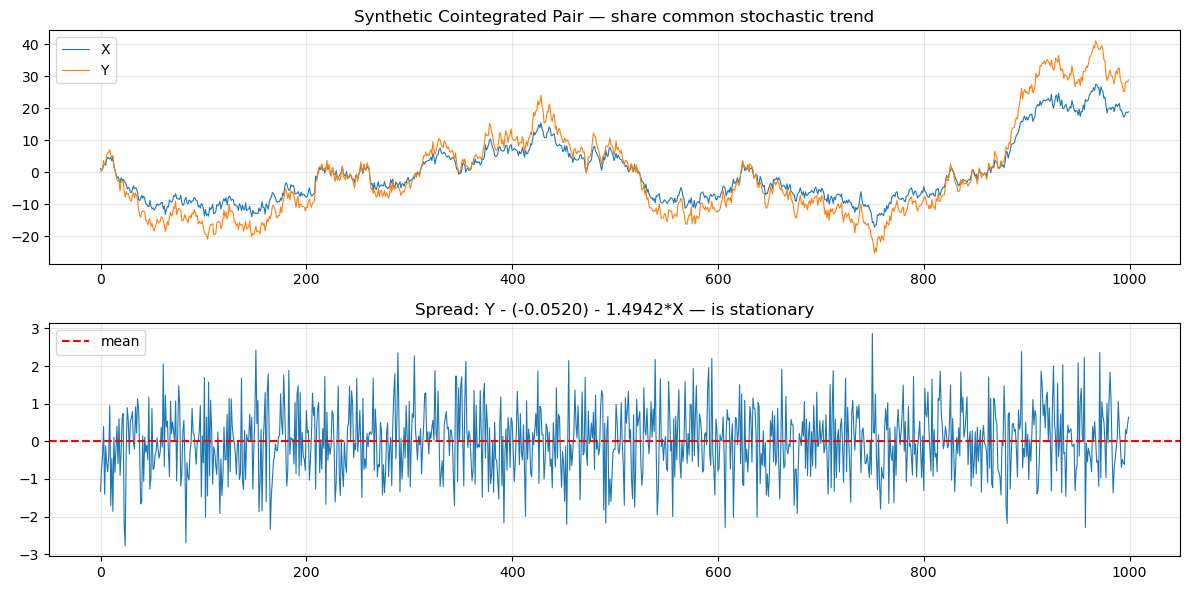

In [87]:
# ── Part A: Synthetic Cointegrated Pair ──────────────────────────────────────
np.random.seed(42)
T = 1000

# Common stochastic trend — random walk
trend = np.cumsum(np.random.normal(0, 1, T))

# Two assets sharing the same trend
beta_true = 1.5
x = pd.Series(trend + np.random.normal(0, 0.5, T), name="X")
y = pd.Series(beta_true * trend + np.random.normal(0, 0.5, T), name="Y")

# ── Plot the two series ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(x, label="X", linewidth=0.8)
axes[0].plot(y, label="Y", linewidth=0.8)
axes[0].set_title("Synthetic Cointegrated Pair — share common stochastic trend")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Step 1: Estimate beta via OLS with intercept ──────────────────────────────
x_dm = x - x.mean()
y_dm = y - y.mean()
beta_ols = np.sum(x_dm * y_dm) / np.sum(x_dm ** 2)
alpha_ols = y.mean() - beta_ols * x.mean()

print(f"True beta : {beta_true:.4f}")
print(f"OLS beta  : {beta_ols:.4f}")
print(f"OLS alpha : {alpha_ols:.4f}")

# ── Step 2: Compute spread ────────────────────────────────────────────────────
spread = y - alpha_ols - beta_ols * x
spread.name = "spread"

axes[1].plot(spread, linewidth=0.8)
axes[1].axhline(spread.mean(), color='red', linestyle='--', label='mean')
axes[1].set_title(f"Spread: Y - ({alpha_ols:.4f}) - {beta_ols:.4f}*X — is stationary")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

ADF test, OU process fitting and trading signal


ADF test on spread:
ADF stat  : -31.2586
p-value   : 0.0000
5% crit   : -2.8644
Conclusion: COINTEGRATED

OU Process fit:
AR(1) coefficient b : 0.0109
Mean reversion theta: 4.5169
Half-life           : 0.2 days


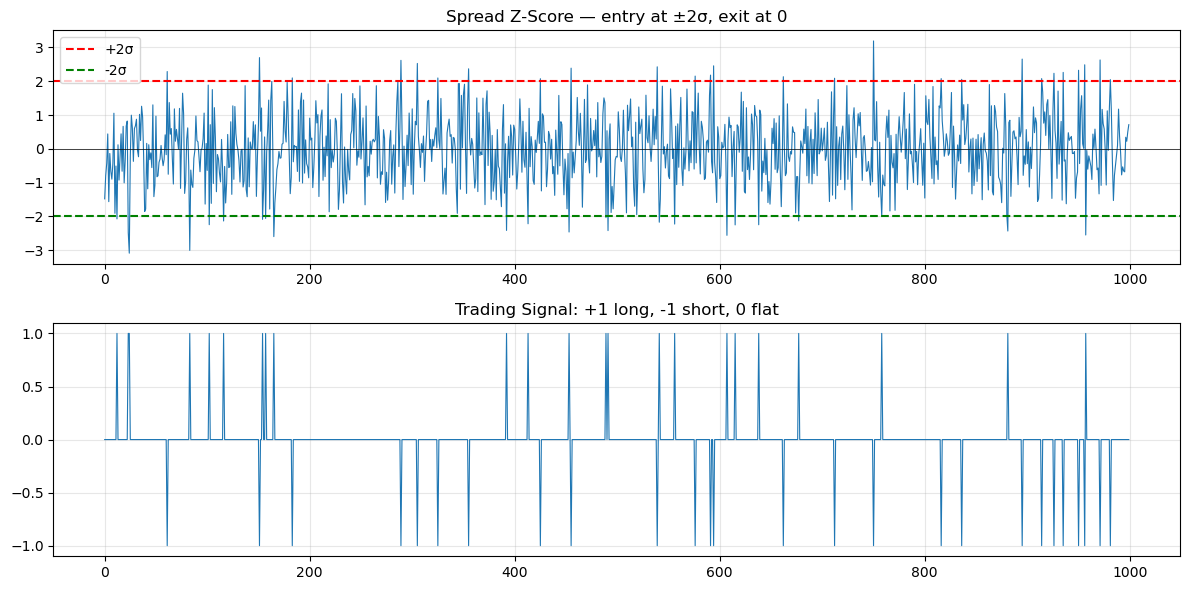

In [89]:
# ── Step 3: ADF test on spread ────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(spread, autolag="AIC")
print(f"\nADF test on spread:")
print(f"ADF stat  : {adf_stat:.4f}")
print(f"p-value   : {adf_p:.4f}")
print(f"5% crit   : {adf_crit['5%']:.4f}")
print(f"Conclusion: {'COINTEGRATED' if adf_p < 0.05 else 'NOT cointegrated'}")

# ── Step 4: OU process fit ────────────────────────────────────────────────────
# Discrete AR(1): S_t = a + b*S_{t-1} + epsilon
# theta = -log(b)/dt,  half-life = log(2)/theta

s = spread.values
s_lag = s[:-1]
s_cur = s[1:]

# OLS on AR(1)
s_lag_dm = s_lag - s_lag.mean()
s_cur_dm = s_cur - s_cur.mean()
b = np.sum(s_lag_dm * s_cur_dm) / np.sum(s_lag_dm ** 2)
a = s_cur.mean() - b * s_lag.mean()

theta    = -np.log(b)          # mean reversion speed
half_life = np.log(2) / theta  # in days

print(f"\nOU Process fit:")
print(f"AR(1) coefficient b : {b:.4f}")
print(f"Mean reversion theta: {theta:.4f}")
print(f"Half-life           : {half_life:.1f} days")

# ── Step 5: Trading signal ────────────────────────────────────────────────────
# Z-score of spread
spread_mean = spread.mean()
spread_std  = spread.std()
z_score = (spread - spread_mean) / spread_std

# Signal: +1 long spread, -1 short spread, 0 flat
signal = pd.Series(0, index=spread.index)
signal[z_score < -2] =  1   # spread cheap — long
signal[z_score >  2] = -1   # spread expensive — short
signal[z_score.abs() < 0.5] = 0  # exit at 0.5

# Plot z-score and signal
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(z_score, linewidth=0.8)
axes[0].axhline( 2, color='red',   linestyle='--', label='+2σ')
axes[0].axhline(-2, color='green', linestyle='--', label='-2σ')
axes[0].axhline( 0, color='black', linewidth=0.5)
axes[0].set_title("Spread Z-Score — entry at ±2σ, exit at 0")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(signal, linewidth=0.8)
axes[1].set_title("Trading Signal: +1 long, -1 short, 0 flat")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Part B — Dynamic Hedge Ratio (Real Data: GLD/GDX)
Static cointegration fails over the full 2010-2026 sample — the relationship between
GLD and GDX is time-varying. Kalman filter tracks the dynamic hedge ratio β_t,
producing a stationary spread where the static approach fails.

Hedge Ratio: 0.6750


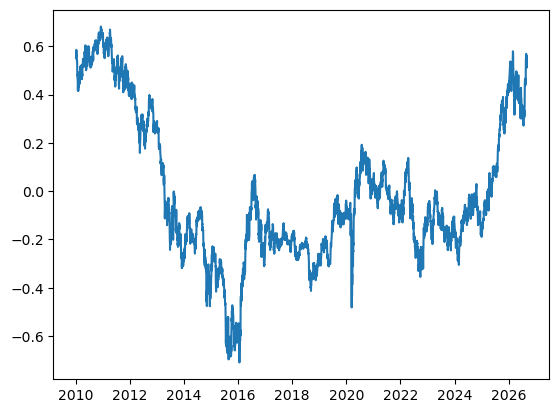

ADF stat  : -1.9125
p-value   : 0.3262
5% crit   : -2.8622
Conclusion: NOT cointegrated


In [91]:
df = prices[['GLD', "GDX"]]
log_GDX = np.log(df['GDX']).dropna()
log_GLD = np.log(df['GLD']).dropna()
hedge_ratio = (np.sum(log_GDX*log_GLD)) / np.sum(log_GLD**2)
print(f"Hedge Ratio: {hedge_ratio:.4f}")
df['spread'] = log_GDX - hedge_ratio*log_GLD
df = df.dropna()


plt.plot(df['spread'])
plt.show()

from statsmodels.tsa.stattools import adfuller
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(df['spread'], autolag="AIC")
print(f"ADF stat  : {adf_stat:.4f}")
print(f"p-value   : {adf_p:.4f}")
print(f"5% crit   : {adf_crit['5%']:.4f}")
print(f"Conclusion: {'COINTEGRATED' if adf_p < 0.05 else 'NOT cointegrated'}")

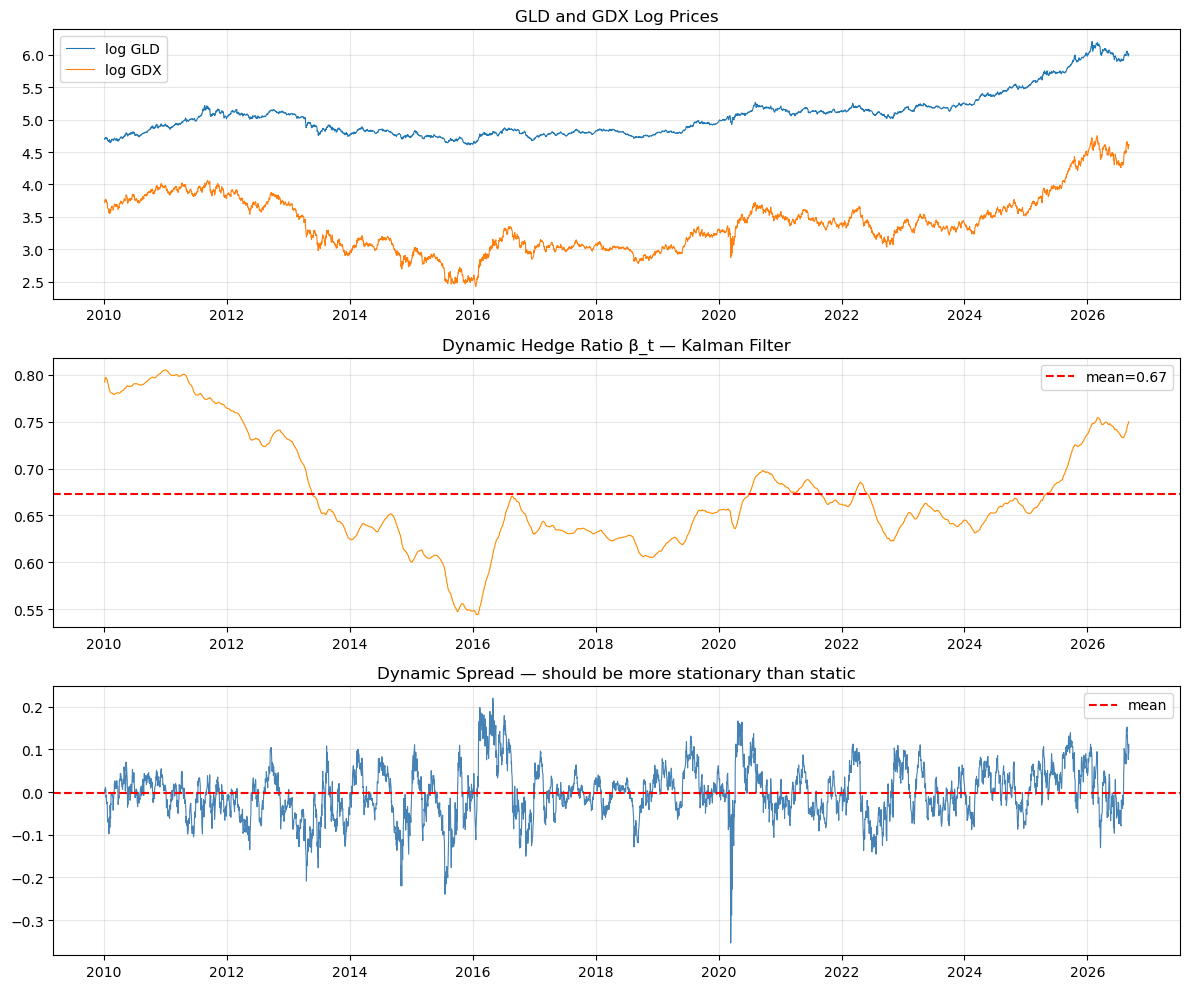


ADF test on dynamic spread:
ADF stat  : -8.9934
p-value   : 0.0000
5% crit   : -2.8622
Conclusion: STATIONARY


In [93]:
# ── Part B: Kalman Filter — Dynamic Hedge Ratio ───────────────────────────────

def kalman_filter(x, y, delta=1e-5):
    T = len(x)
    
    beta    = np.zeros(T)      # state estimate (hedge ratio)
    P       = np.zeros(T)      # state variance (hedge ratio uncertainty)
    R       = np.var(y)        # observation noise — initialized to return variance
    Q       = delta            # state noise — controls adaptation speed
    
    beta[0] = y.iloc[0] / x.iloc[0]  # initial hedge ratio
    P[0]    = 1.0                      # initial uncertainty

    for t in range(1, T):
        # ── Predict ──────────────────────────────────────────────────────────
        beta_pred = beta[t-1]           # state prediction
        P_pred    = P[t-1] + Q          # variance prediction

        # ── Update ───────────────────────────────────────────────────────────
        # Innovation — difference between observed and predicted y
        innovation = y.iloc[t] - beta_pred * x.iloc[t]

        # Innovation variance
        S = x.iloc[t]**2 * P_pred + R

        # Kalman gain
        K = P_pred * x.iloc[t] / S

        # Update state and variance
        beta[t] = beta_pred + K * innovation
        P[t]    = (1 - K * x.iloc[t]) * P_pred

        # Update observation noise estimate     R = (1 - K * x.iloc[t]) * R + K**2 * innovation**2

    return pd.Series(beta, index=x.index, name="beta_kalman")


# ── Run Kalman filter ─────────────────────────────────────────────────────────

log_GLD = np.log(prices["GLD"].dropna())
log_GDX = np.log(prices["GDX"].dropna())

# Align indices
idx = log_GLD.index.intersection(log_GDX.index)
log_GLD = log_GLD[idx]
log_GDX = log_GDX[idx]

beta_kalman = kalman_filter(log_GLD, log_GDX)

# ── Dynamic spread ────────────────────────────────────────────────────────────
spread_dynamic = log_GDX - beta_kalman * log_GLD
spread_dynamic.name = "dynamic_spread"

# ── Plot beta over time ───────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(log_GLD, label="log GLD", linewidth=0.8)
axes[0].plot(log_GDX, label="log GDX", linewidth=0.8)
axes[0].set_title("GLD and GDX Log Prices")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(beta_kalman, linewidth=0.8, color="darkorange")
axes[1].axhline(beta_kalman.mean(), color="red", linestyle="--", label=f"mean={beta_kalman.mean():.2f}")
axes[1].set_title("Dynamic Hedge Ratio β_t — Kalman Filter")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(spread_dynamic, linewidth=0.8, color="steelblue")
axes[2].axhline(spread_dynamic.mean(), color="red", linestyle="--", label="mean")
axes[2].set_title("Dynamic Spread — should be more stationary than static")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── ADF on dynamic spread ─────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(spread_dynamic.dropna(), autolag="AIC")
print(f"\nADF test on dynamic spread:")
print(f"ADF stat  : {adf_stat:.4f}")
print(f"p-value   : {adf_p:.4f}")
print(f"5% crit   : {adf_crit['5%']:.4f}")
print(f"Conclusion: {'STATIONARY' if adf_p < 0.05 else 'NOT stationary'}")